# 120.LeNet-5 (1998, Yan LeCunn)

필요한 라이브러리를 import 합니다. LeNet-5는 합성곱 신경망(CNN)을 사용하여 손글씨 숫자를 분류하는 모델입니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, AveragePooling2D, Flatten, Dense
)

from tensorflow.keras.datasets import mnist

### train, test split

MNIST 데이터셋을 로드합니다. 28x28 크기의 손글씨 숫자 이미지로 구성되어 있으며, 0부터 9까지 10개의 클래스로 분류합니다.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### scaling
- 0 `~` 1 사이로 pixel 값을 scale

픽셀 값을 0-1 사이로 정규화합니다. 원본 이미지의 픽셀 값은 0-255 범위이므로 255로 나누어 정규화합니다.

In [3]:
X_train_scaled = X_train / 255.
X_test_scaled = X_test / 255.

### Conv2D layer 의  입력 사양에 맞추어 3 dimension 으로 차원 증가

Conv2D 레이어의 입력 형식에 맞추기 위해 채널 차원을 추가합니다. (높이, 너비) 형태를 (높이, 너비, 채널) 형태로 변환합니다.

In [4]:
X_train_scaled = np.expand_dims(X_train_scaled, axis=3)
X_test_scaled = np.expand_dims(X_test_scaled, axis=3)

차원 증가 후 데이터의 형태를 확인합니다. (샘플 수, 높이, 너비, 채널) 형태가 되어야 합니다.

In [5]:
X_train_scaled.shape
X_test_scaled.shape

(10000, 28, 28, 1)

### label 을 one-hot-encoding

라벨을 원-핫 인코딩으로 변환합니다. 다중 분류 문제이므로 각 클래스를 이진 벡터로 표현합니다. 예를 들어, 숫자 3은 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]로 변환됩니다.

In [6]:
y_train_onehot = tf.keras.utils.to_categorical(y_train)
y_test_onehot = tf.keras.utils.to_categorical(y_test)

y_train_onehot.shape, y_test_onehot.shape

((60000, 10), (10000, 10))

## tf.data 를 이용한 shuffling and batch 구성

tf.data.Dataset을 사용하여 데이터를 셔플하고 배치로 구성합니다. 훈련 데이터는 10000개를 버퍼로 사용하여 셔플하고, 배치 크기는 128로 설정합니다.

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train_onehot)).shuffle(10000).batch(128)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test_onehot)).batch(128)

## LeNet 구성

<img src="https://d2l.ai/_images/lenet.svg" width="800" />

LeNet-5 모델을 구성합니다. 합성곱 레이어 2개, 풀링 레이어 2개, 완전 연결 레이어 3개로 구성되어 있습니다. 마지막 출력층은 10개 클래스를 분류하기 위해 softmax 활성화 함수를 사용합니다.

In [8]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(6, kernel_size=5, padding="same", activation="relu"),
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid"),

    Conv2D(16, kernel_size=5, padding="valid", activation="relu"),
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid"),

    Flatten(),

    Dense(120, activation="relu"),
    Dense(84, activation="relu"),
    Dense(10, activation="softmax"),
])

모델의 구조를 요약하여 출력합니다. 각 레이어의 파라미터 수와 모델의 전체 구조를 확인할 수 있습니다.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

모델을 컴파일합니다. 다중 분류 문제이므로 손실 함수는 categorical_crossentropy를 사용하고, 옵티마이저는 adam을 사용합니다. 평가 지표로 accuracy를 사용합니다.

In [10]:
model.compile(loss="categorical_crossentropy",
              optimizer='adam', metrics=['accuracy'])

모델을 학습시킵니다. epochs=5로 설정하고, validation_data로 테스트 데이터를 사용하여 검증 손실과 정확도를 모니터링합니다.

In [11]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7750 - loss: 0.7623 - val_accuracy: 0.9597 - val_loss: 0.1290
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9631 - loss: 0.1186 - val_accuracy: 0.9758 - val_loss: 0.0756
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9758 - loss: 0.0825 - val_accuracy: 0.9823 - val_loss: 0.0567
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9796 - loss: 0.0646 - val_accuracy: 0.9818 - val_loss: 0.0592
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9842 - loss: 0.0507 - val_accuracy: 0.9863 - val_loss: 0.0452
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9866 - loss: 0.0420 - val_accuracy: 0.9868 - val_loss: 0.0405
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9891 - loss: 0.0357 - val_accuracy: 0.9887 - val_loss: 0.0363
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.

학습된 모델을 테스트 데이터로 평가합니다. 테스트 손실과 정확도를 확인할 수 있습니다.

In [12]:
score = model.evaluate(test_ds, verbose=0)

평가 결과를 출력합니다. Test Score는 손실 값, Test Accuracy는 정확도를 나타냅니다.

In [13]:
print("Test Score ", score[0])
print("Test Accuracy ", score[1])

Test Score  0.03753896802663803
Test Accuracy  0.9878000020980835


학습 과정을 시각화합니다. 훈련 데이터와 검증 데이터의 정확도와 손실을 그래프로 표시하여 모델의 학습 과정과 과적합 여부를 확인할 수 있습니다.

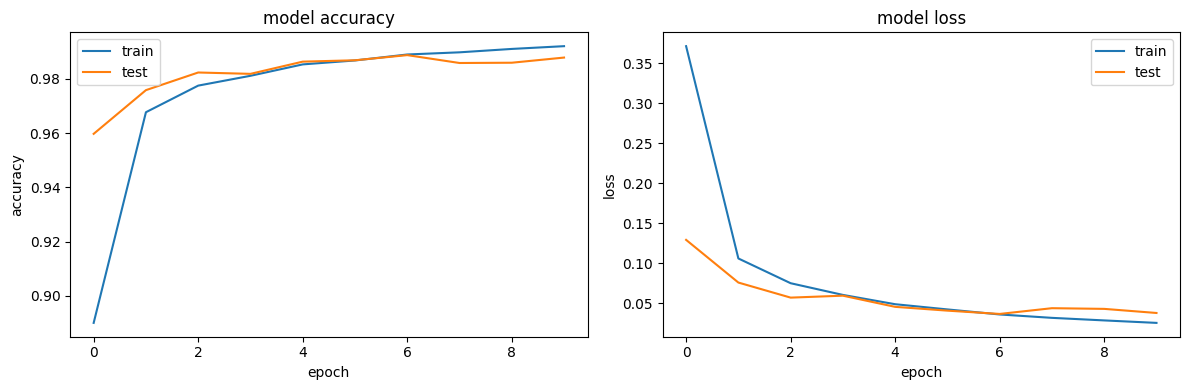

In [14]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.tight_layout()
plt.show()

학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다. predict()는 각 클래스에 대한 확률을 반환하므로, argmax를 사용하여 가장 높은 확률을 가진 클래스를 선택합니다.

In [17]:
predictions = model.predict(X_test_scaled)
y_pred = np.argmax(predictions, axis=-1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([7, 2, 1, ..., 4, 5, 6])

실제 테스트 라벨을 확인합니다.

In [ ]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

혼동 행렬을 계산합니다. 실제 라벨과 예측 라벨의 일치 여부를 확인할 수 있습니다.

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score

print(confusion_matrix(y_test, y_pred))

[[ 978    0    0    0    0    0    0    1    1    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    2 1026    0    0    0    0    4    0    0]
 [   1    0    1  999    0    2    0    2    2    3]
 [   0    1    2    0  970    0    1    0    0    8]
 [   2    0    0   13    0  874    1    2    0    0]
 [   6    4    0    0    1    4  942    0    1    0]
 [   0    2    6    0    0    0    0 1016    1    3]
 [   4    3    7    3    0    3    1    2  945    6]
 [   2    3    0    2    4    1    0    4    0  993]]


혼동 행렬을 시각화합니다. 각 숫자 클래스별로 올바르게 분류된 개수와 잘못 분류된 개수를 색상으로 표현하여 한눈에 확인할 수 있습니다.

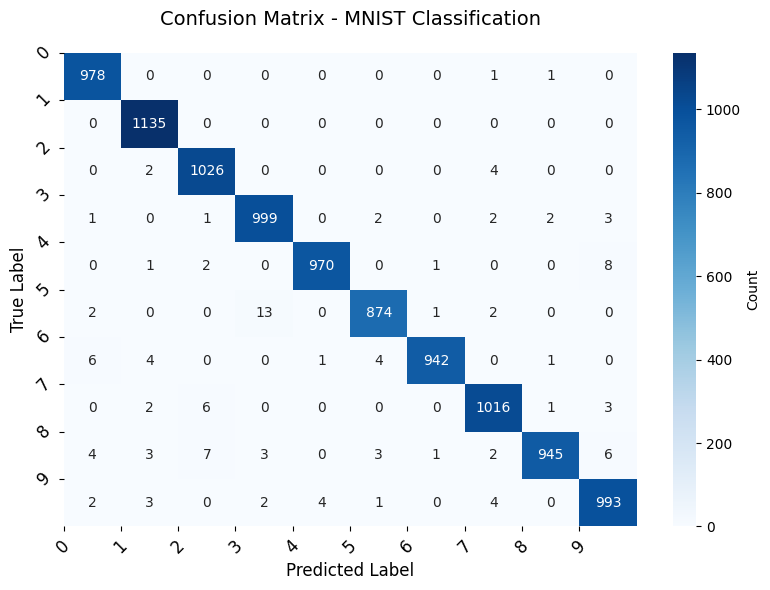

Test Accuracy : 0.9878


In [19]:
import seaborn as sns

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(10)),
            yticklabels=list(range(10)),
            cbar_kws={'label': 'Count'})

plt.xticks(np.arange(10), list(range(10)), rotation=45, fontsize=12)
plt.yticks(np.arange(10), list(range(10)), rotation=45, fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title('Confusion Matrix - MNIST Classification', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('Test Accuracy :', accuracy_score(y_test, y_pred))

# 실습 : fashion MNIST 를 이용하여 위와 동일한 작업

Fashion MNIST 데이터셋을 사용하여 위와 동일한 방식으로 LeNet 모델을 학습시킵니다.

Label	Class  
0	T-shirt/top  
1	Trouser  
2	Pullover  
3	Dress  
4	Coat  
5	Sandal  
6	Shirt  
7	Sneaker  
8	Bag  
9	Ankle boot

필요한 라이브러리를 import 합니다. Fashion MNIST 데이터셋을 사용하여 의류 이미지를 분류합니다.

Fashion MNIST 데이터셋을 로드합니다. 28x28 크기의 의류 이미지로 구성되어 있으며, 10개의 클래스로 분류합니다.

In [20]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


클래스 이름을 정의합니다. 각 숫자 라벨에 대응하는 의류 종류를 나타냅니다.

In [21]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

훈련 데이터의 처음 25개 이미지를 시각화하여 데이터를 확인합니다.

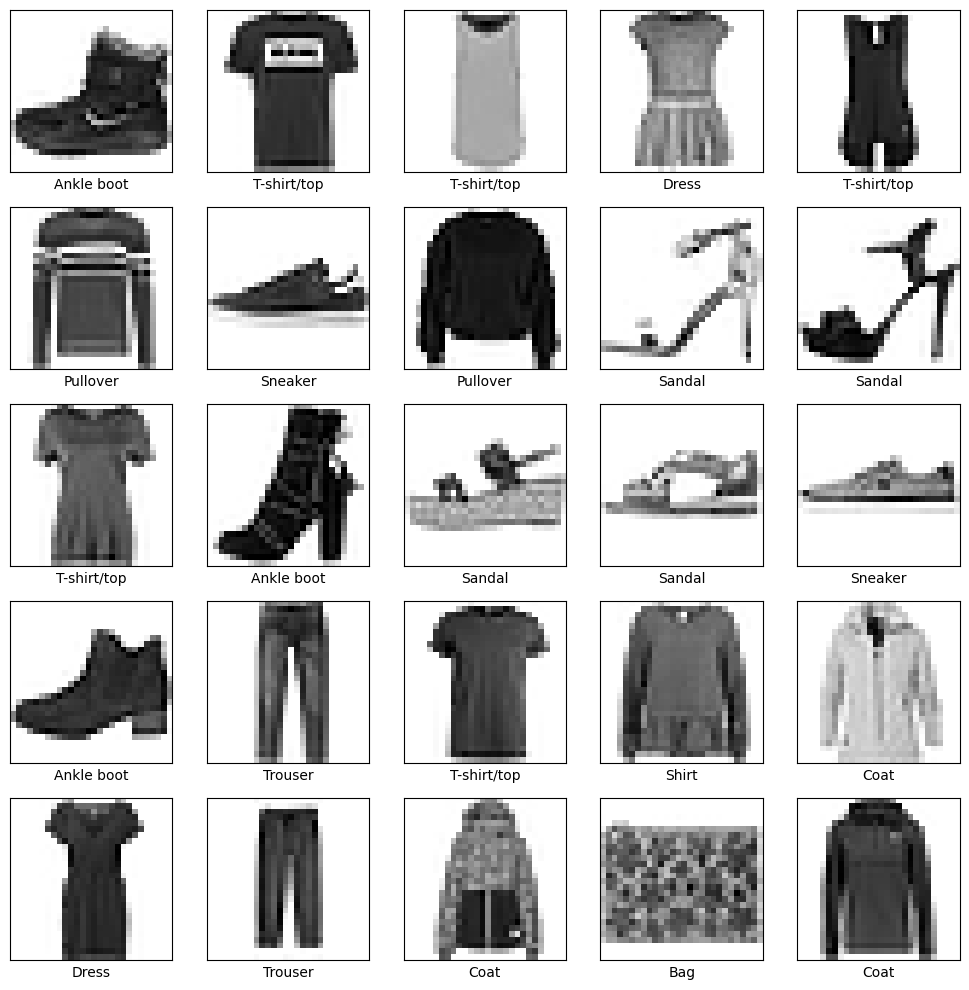

In [22]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
plt.tight_layout()
plt.show()

픽셀 값을 0-1 사이로 정규화합니다. 원본 이미지의 픽셀 값은 0-255 범위이므로 255로 나누어 정규화합니다.

In [23]:
X_train = train_images / 255.0
X_test  = test_images / 255.0

Conv2D 레이어의 입력 형식에 맞추기 위해 채널 차원을 추가합니다. (높이, 너비) 형태를 (높이, 너비, 채널) 형태로 변환합니다.

In [ ]:
# Conv2D layer 의  입력 사양에 맞추어 3 dimension 으로 차원 증가
# your code here
# 힌트: np.expand_dims()를 사용하여 axis=3으로 채널 차원을 추가하세요.

라벨을 원-핫 인코딩으로 변환합니다. 다중 분류 문제이므로 각 클래스를 이진 벡터로 표현합니다.

In [ ]:
# label 을 one-hot-encoding
# your code here
# 힌트: tf.keras.utils.to_categorical()을 사용하여 라벨을 원-핫 인코딩하세요.

tf.data.Dataset을 사용하여 데이터를 셔플하고 배치로 구성합니다. 훈련 데이터는 셔플하고, 배치 크기는 128로 설정합니다.

In [ ]:
# tf.data 를 이용한 shuffling and batch 구성
# your code here
# 힌트: tf.data.Dataset.from_tensor_slices()를 사용하고, shuffle()과 batch()를 적용하세요.

LeNet-5 모델을 구성합니다. 위의 MNIST 예제와 동일한 구조로 모델을 만듭니다.

In [ ]:
# LeNet model 구성
# your code here
# 힌트: 위의 MNIST 예제와 동일한 구조로 Sequential 모델을 구성하세요.
# Conv2D(6, kernel_size=5) -> AveragePooling2D -> Conv2D(16, kernel_size=5) -> AveragePooling2D
# -> Flatten -> Dense(120) -> Dense(84) -> Dense(10, activation='softmax')

모델을 컴파일하고 학습시킵니다. 손실 함수는 categorical_crossentropy, 옵티마이저는 adam을 사용합니다.

In [ ]:
# model compile and predict
# your code here
# 힌트: model.compile()로 모델을 컴파일하고, model.fit()으로 학습시키세요.

학습 과정을 시각화합니다. 훈련 데이터와 검증 데이터의 정확도와 손실을 그래프로 표시합니다.

In [ ]:
# train history 시각화
# your code here
# 힌트: history.history['accuracy'], history.history['val_accuracy'] 등을 사용하여 그래프를 그리세요.

혼동 행렬을 계산하고 시각화합니다. 각 의류 클래스별로 올바르게 분류된 개수와 잘못 분류된 개수를 확인합니다.

In [ ]:
# confusion matrix 시각화
# your code here
# 힌트: confusion_matrix()를 계산하고, sns.heatmap()으로 시각화하세요.